<a href="https://colab.research.google.com/github/sayedmhabibullah51-beep/Python/blob/master/Exam_Week_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## **Data Understanding & Exploration**

## Q1. Load and inspect the dataset

In [21]:
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print(path)

csv_path = "/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(csv_path)

df.head()

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
/kaggle/input/telco-customer-churn


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [22]:
df.shape

(7043, 21)

In [23]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [24]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [26]:
target_classification = "Churn"
target_regression = "MonthlyCharges"

## **Q2. Perform Exploratory Data Analysis (EDA)**

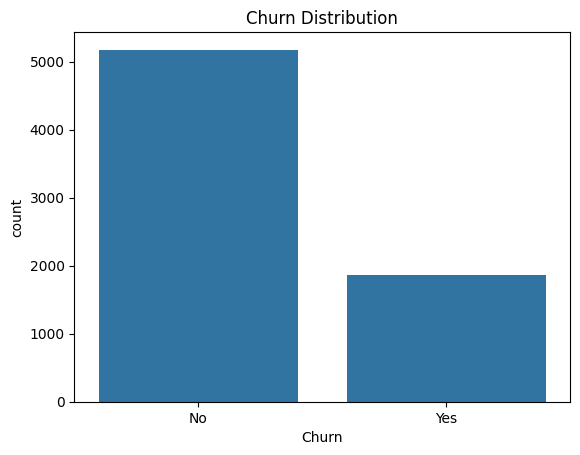

In [27]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

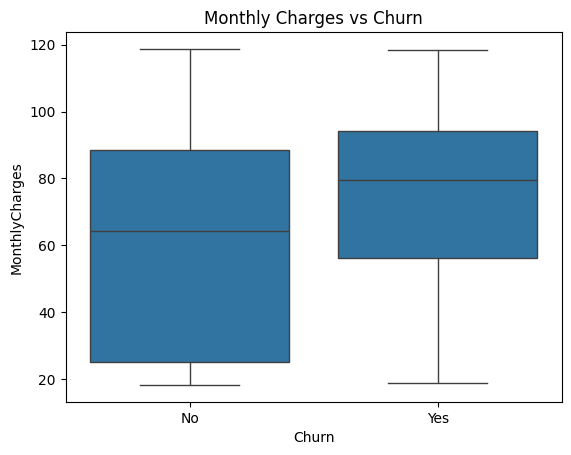

In [28]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

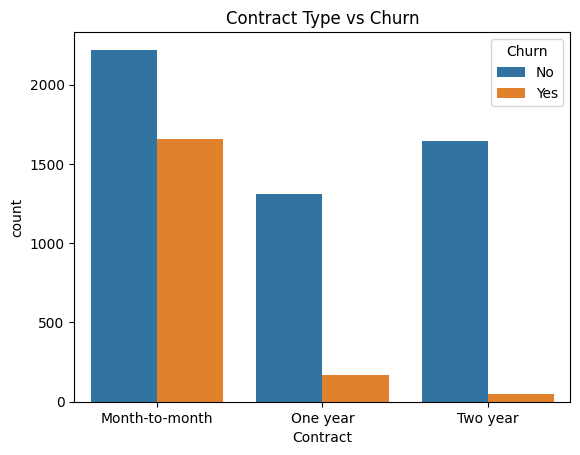

In [29]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Contract Type vs Churn")
plt.show()

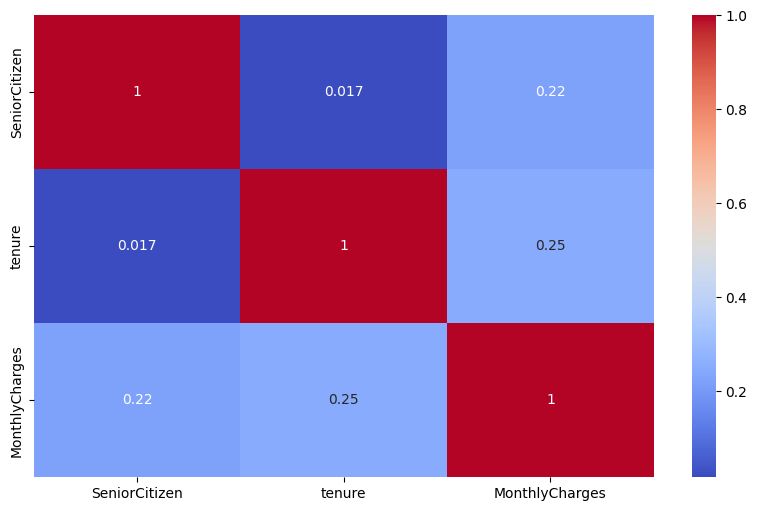

In [30]:
numeric_df = df.select_dtypes(include=["int64", "float64"])
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.show()

## **Data Preprocessing**

# Q3. Handle missing values and data cleaning

In [31]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [32]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [33]:
df['TotalCharges']=df["TotalCharges"].fillna(df["TotalCharges"].median())

# Q4. Feature encoding and scaling

In [34]:
df.drop("customerID", axis=1, inplace=True)

In [35]:
label_encoder = LabelEncoder()
df["Churn"] = label_encoder.fit_transform(df["Churn"])

In [36]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [37]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_encoded.drop(["Churn"], axis=1))

In [38]:
X = pd.DataFrame(scaled_features, columns=df_encoded.drop("Churn", axis=1).columns)
y = df_encoded["Churn"]

# **Classification – Customer Churn Prediction**

# Q5. Logistic Regression Model

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [40]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [42]:
y_pred_log = log_model.predict(X_test)
y_pred_log

array([1, 0, 0, ..., 0, 0, 0])

# Q6. Model Evaluation

In [43]:
log_accuracy = accuracy_score(y_test, y_pred_log)
log_precision = precision_score(y_test, y_pred_log)
log_recall = recall_score(y_test, y_pred_log)
log_f1 = f1_score(y_test, y_pred_log)

log_accuracy, log_precision, log_recall, log_f1

(0.8197303051809794, 0.683076923076923, 0.5951742627345844, 0.6361031518624641)

In [44]:
confusion_matrix(y_test, y_pred_log)

array([[933, 103],
       [151, 222]])

# Q7. Random Forest Classifier

In [45]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [46]:
y_pred_rf = rf_model.predict(X_test)

In [47]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

rf_accuracy, rf_precision, rf_recall, rf_f1

(0.7913413768630234, 0.6479400749063671, 0.46380697050938335, 0.540625)

**Random Forest Classifier outperforms Logistic Regression across all evaluation metrics.**

# **Regression – Monthly Charges Prediction**

# Q8. Define regression problem & select features

In [49]:
X_reg = df_encoded.drop("MonthlyCharges", axis=1)
y_reg = df_encoded["MonthlyCharges"]

# Q9.Build Linear Regression model

In [50]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

In [51]:
lin_model = LinearRegression()
lin_model.fit(X_train_r, y_train_r)

LinearRegression()

In [52]:
y_pred_r = lin_model.predict(X_test_r)

# Q10.Evaluate regression model

In [54]:
mae = mean_absolute_error(y_test_r, y_pred_r)
mse = mean_squared_error(y_test_r, y_pred_r)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_r, y_pred_r)

mae, mse, rmse, r2

(0.7888187418600427,
 1.0992023378727058,
 np.float64(1.0484285087084888),
 0.9987859143498585)

**Interpretation:**
The model shows strong predictive performance with a high R² score indicating good explanatory power.

# **Business Insights & Conclusion**

# Q11. Derive insights from classification results

Customers with month-to-month contracts churn more than long-term customers. Higher MonthlyCharges increase churn. Customers without online security or tech support are more likely to leave. Short-tenure customers show higher churn. These insights help the business identify high-risk customers and take action to reduce customer loss.

# Q12. Final conclusion and recommendations

In this project, customer churn was analyzed using classification models and monthly charges were predicted using a regression model. The Random Forest model performed better than Logistic Regression for churn prediction. The analysis shows that contract type, pricing and service quality strongly affect customer churn.

To reduce churn, the company should encourage customers to take long-term contracts improve customer support services and provide offers to customers who are likely to churn. One limitation of this project is that it is based on past data only. In the future, more advanced models and time-based customer behavior analysis can be used for better results.